**MÁSTER EN BIG DATA DEPORTIVO**

**Módulo 7. Proveedores de datos deportivos. Tarea Individual**

**Mateo Gandarillas Seco**

In [ ]:
#Cargar librerias
!pip install mplsoccer
!pip install cmasher
!pip install highlight_text

In [ ]:
from mplsoccer import VerticalPitch, Pitch, FontManager, Sbopen #En el caso de tener acceso a la API de Sb se substituye Sbopen por Sblocal
from matplotlib.colors import LinearSegmentedColormap, to_rgba
from matplotlib import rcParams
import matplotlib.pyplot as plt
import pandas as pd
import cmasher as cmr
import numpy as np
from scipy.ndimage import gaussian_filter
from matplotlib import cm
import matplotlib.patheffects as path_effects
import seaborn as sns
import warnings
from highlight_text import ax_text
import warnings
import matplotlib.patheffects as pe
from matplotlib import colormaps

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [ ]:
#Extraer información de la competición
parser = Sbopen()
df_competition = parser.competition()
df_competition

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882
5,16,2,Europe,Champions League,male,False,False,2016/2017,2024-02-13T02:37:32.205154,2021-06-13T16:17:31.694,None,2024-02-13T02:37:32.205154
6,16,27,Europe,Champions League,male,False,False,2015/2016,2024-06-12T07:45:38.786894,2021-06-13T16:17:31.694,None,2024-06-12T07:45:38.786894
7,16,26,Europe,Champions League,male,False,False,2014/2015,2024-02-12T12:49:54.914228,2021-06-13T16:17:31.694,None,2024-02-12T12:49:54.914228
8,16,25,Europe,Champions League,male,False,False,2013/2014,2024-02-12T12:48:48.479157,2021-06-13T16:17:31.694,None,2024-02-12T12:48:48.479157
9,16,24,Europe,Champions League,male,False,False,2012/2013,2024-02-12T12:47:34.340413,2021-06-13T16:17:31.694,None,2024-02-12T12:47:34.340413


In [ ]:
df_champions = df_competition[df_competition["competition_name"] == "Champions League"]
df_champions

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882
5,16,2,Europe,Champions League,male,False,False,2016/2017,2024-02-13T02:37:32.205154,2021-06-13T16:17:31.694,None,2024-02-13T02:37:32.205154
6,16,27,Europe,Champions League,male,False,False,2015/2016,2024-06-12T07:45:38.786894,2021-06-13T16:17:31.694,None,2024-06-12T07:45:38.786894
7,16,26,Europe,Champions League,male,False,False,2014/2015,2024-02-12T12:49:54.914228,2021-06-13T16:17:31.694,None,2024-02-12T12:49:54.914228
8,16,25,Europe,Champions League,male,False,False,2013/2014,2024-02-12T12:48:48.479157,2021-06-13T16:17:31.694,None,2024-02-12T12:48:48.479157
9,16,24,Europe,Champions League,male,False,False,2012/2013,2024-02-12T12:47:34.340413,2021-06-13T16:17:31.694,None,2024-02-12T12:47:34.340413
10,16,23,Europe,Champions League,male,False,False,2011/2012,2024-02-13T02:36:35.698340,2021-06-13T16:17:31.694,None,2024-02-13T02:36:35.698340
11,16,22,Europe,Champions League,male,False,False,2010/2011,2024-02-12T12:53:03.944320,2021-06-13T16:17:31.694,None,2024-02-12T12:53:03.944320
12,16,21,Europe,Champions League,male,False,False,2009/2010,2024-02-12T12:49:25.017694,2021-06-13T16:17:31.694,None,2024-02-12T12:49:25.017694


In [ ]:
#Extraer los eventos para la competición que me interesa
df_matches = parser.match(competition_id= 16, season_id= 1)
df_matches

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_id,country_name,competition_name,season_id,season_name,home_team_id,home_team_name,home_team_gender,home_team_group,home_team_country_id,home_team_country_name,home_team_managers_id,home_team_managers_name,home_team_managers_nickname,home_team_managers_dob,home_team_managers_country_id,home_team_managers_country_name,away_team_id,away_team_name,away_team_gender,away_team_group,away_team_country_id,away_team_country_name,away_team_managers_id,away_team_managers_name,away_team_managers_nickname,away_team_managers_dob,away_team_managers_country_id,away_team_managers_country_name,metadata_data_version,metadata_shot_fidelity_version,metadata_xy_fidelity_version,competition_stage_id,competition_stage_name,stadium_id,stadium_name,stadium_country_id,stadium_country_name,referee_id,referee_name,referee_country_id,referee_country_name
0,18245,2018-05-26,2018-05-26 20:45:00,3,1,available,scheduled,2021-01-23 21:55:30.425330,2021-06-13 16:17:31.694,7,16,Europe,Champions League,1,2017/2018,220,Real Madrid,male,None,214,Spain,56,Zinédine Zidane,Zinédine Zidane,1972-06-23,78,France,24,Liverpool,male,None,68,England,94,Jürgen Klopp,Jürgen Klopp,1967-06-16,85,Germany,1.1.0,2,2,26,Final,4222,NSK Olimpiyskyi,238,Ukraine,727,Milorad Mažić,203,Serbia


In [ ]:
#Ver las alineaciones
matchId = 18245
lineups = parser.lineup(matchId)
lineups.head()

,player_id,player_name,player_nickname,jersey_number,match_id,team_id,team_name,country_id,country_name
0,3471,Dejan Lovren,Dejan Lovren,6,18245,24,Liverpool,56,Croatia
1,3473,James Philip Milner,James Milner,7,18245,24,Liverpool,68,England
2,3493,Emre Can,Emre Can,23,18245,24,Liverpool,85,Germany
3,3515,Alberto Moreno Pérez,Alberto Moreno,18,18245,24,Liverpool,214,Spain
4,3531,Mohamed Salah,Mohamed Salah,11,18245,24,Liverpool,66,Egypt


In [ ]:
lineups.columns

Index(['player_id', 'player_name', 'player_nickname', 'jersey_number',
       'match_id', 'team_id', 'team_name', 'country_id', 'country_name'],
      dtype='object')

In [ ]:
events, related, freeze, players= parser.event(matchId)
players

,jersey_number,match_id,id,player_id,player_name,position_id,position_name,event_tactics_id
0,1,18245,5eee3ffd-f0c0-4532-868b-4a66cbf20cb8,5597,Keylor Navas Gamboa,1,Goalkeeper,1
1,2,18245,5eee3ffd-f0c0-4532-868b-4a66cbf20cb8,5721,Daniel Carvajal Ramos,2,Right Back,2
2,5,18245,5eee3ffd-f0c0-4532-868b-4a66cbf20cb8,5485,Raphaël Varane,3,Right Center Back,3
3,4,18245,5eee3ffd-f0c0-4532-868b-4a66cbf20cb8,5201,Sergio Ramos García,5,Left Center Back,4
4,12,18245,5eee3ffd-f0c0-4532-868b-4a66cbf20cb8,5552,Marcelo Vieira da Silva Júnior,6,Left Back,5
5,14,18245,5eee3ffd-f0c0-4532-868b-4a66cbf20cb8,5539,Carlos Henrique Casimiro,10,Center Defensive Midfield,6
6,10,18245,5eee3ffd-f0c0-4532-868b-4a66cbf20cb8,5463,Luka Modrić,13,Right Center Midfield,7
7,8,18245,5eee3ffd-f0c0-4532-868b-4a66cbf20cb8,5574,Toni Kroos,15,Left Center Midfield,8
8,22,18245,5eee3ffd-f0c0-4532-868b-4a66cbf20cb8,4926,Francisco Román Alarcón Suárez,19,Center Attacking Midfield,9
9,9,18245,5eee3ffd-f0c0-4532-868b-4a66cbf20cb8,19677,Karim Benzema,22,Right Center Forward,10


In [ ]:
#Observamos las filas y columnas de cada dataframe

print ("events "   ,events.shape)
print ("related "  ,related.shape)
print ("freeze "   ,freeze.shape)
print ("players "  ,players.shape)

events  (3497, 72)
related  (6530, 7)
freeze  (361, 10)
players  (55, 8)


# **1ª Parte. Visualización de los pases de un jugador**
Se llevará a cabo una visualización en formato de campograma que representará todos los pases realizados por **Toni Kroos** en la final de la UEFA Champions League 2017/2018, disputada entre el Real Madrid y el Liverpool FC

In [ ]:
Toni_Kroos = lineups[lineups["player_name"] == "Toni Kroos"]
Toni_Kroos

,player_id,player_name,player_nickname,jersey_number,match_id,team_id,team_name,country_id,country_name
28,5574,Toni Kroos,Toni Kroos,8,18245,220,Real Madrid,85,Germany


In [ ]:
events.type_name.unique()

array(['Starting XI', 'Half Start', 'Pass', 'Ball Receipt', 'Carry',
       'Ball Recovery', 'Pressure', 'Clearance', 'Foul Won',
       'Foul Committed', 'Miscontrol', 'Dispossessed', 'Duel',
       'Dribbled Past', 'Dribble', 'Block', 'Shot', 'Goal Keeper',
       'Interception', 'Error', '50/50', 'Injury Stoppage',
       'Substitution', 'Tactical Shift', 'Offside', 'Half End'],
      dtype=object)

In [ ]:
events.columns

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession',
       'duration', 'match_id', 'type_id', 'type_name', 'possession_team_id',
       'possession_team_name', 'play_pattern_id', 'play_pattern_name',
       'team_id', 'team_name', 'tactics_formation', 'player_id', 'player_name',
       'position_id', 'position_name', 'pass_recipient_id',
       'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id',
       'pass_height_name', 'end_x', 'end_y', 'sub_type_id', 'sub_type_name',
       'body_part_id', 'body_part_name', 'x', 'y', 'outcome_id',
       'outcome_name', 'counterpress', 'under_pressure', 'foul_won_defensive',
       'off_camera', 'pass_switch', 'dribble_overrun', 'dribble_nutmeg',
       'technique_id', 'technique_name', 'out', 'pass_assisted_shot_id',
       'pass_shot_assist', 'shot_statsbomb_xg', 'shot_key_pass_id',
       'goalkeeper_position_id', 'goalkeeper_position_name', 'pass_cross',
       'shot_first_time', 'ball_recovery_recov

In [ ]:
# Filtrar pases de Toni Kroos
mask_kroos = (events["type_name"] == "Pass") & (events["player_name"] == "Toni Kroos")
pases_kroos = events.loc[mask_kroos]
mask_complete = pases_kroos.outcome_name.isnull()

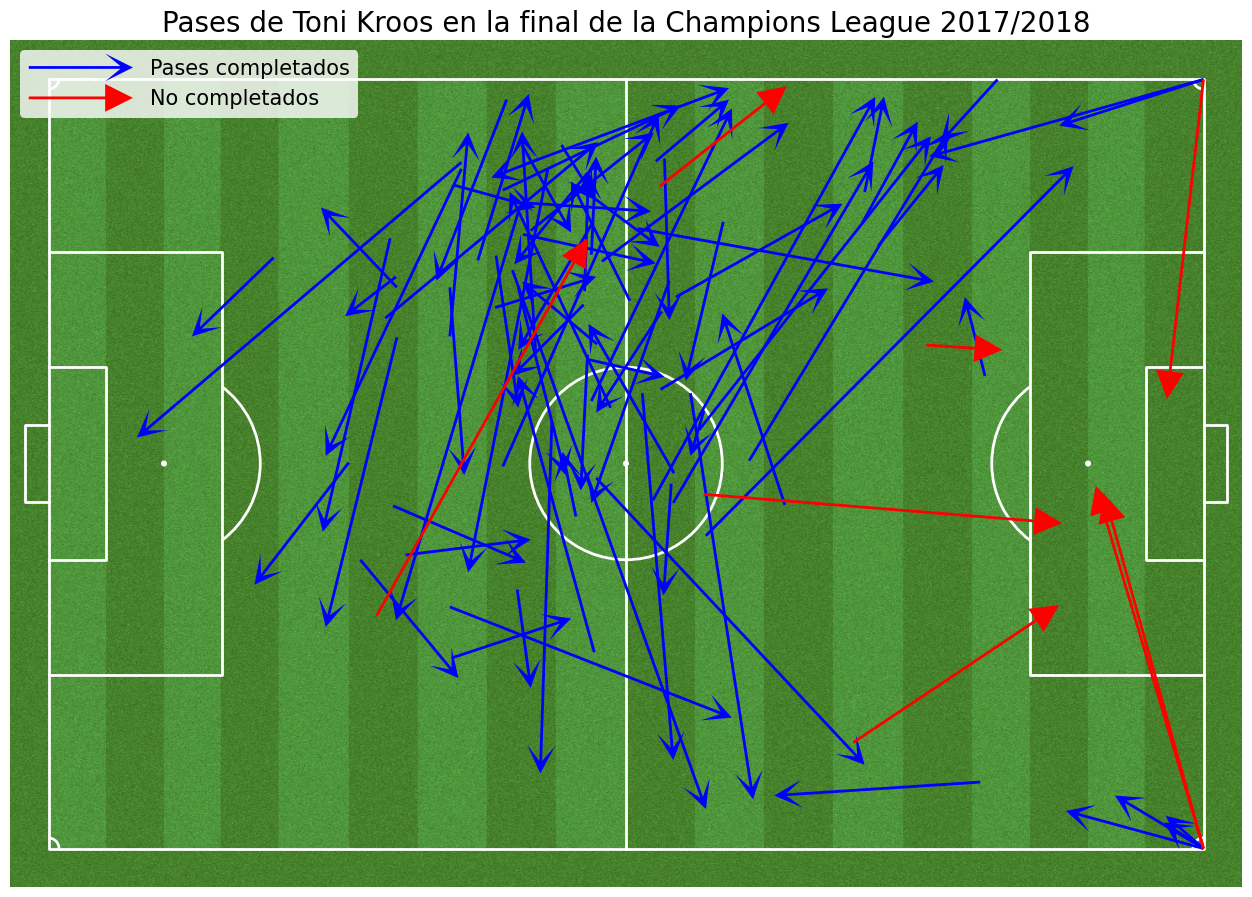

In [ ]:
# Configuración del campo
pitch = Pitch(pitch_type = 'statsbomb', pitch_color = 'grass', line_color='white', stripe=True, goal_type="box", corner_arcs=True)
fig, ax = pitch.draw(figsize=(16, 11), constrained_layout=True, tight_layout=False)
# Pases completados
pitch.arrows(pases_kroos[mask_complete].x, pases_kroos[mask_complete].y,
             pases_kroos[mask_complete].end_x, pases_kroos[mask_complete].end_y, width=2,
             headwidth=10, headlength=10, color='Blue', ax=ax, label='Pases completados')
# Pases fallados
pitch.arrows(pases_kroos[~mask_complete].x, pases_kroos[~mask_complete].y,
             pases_kroos[~mask_complete].end_x, pases_kroos[~mask_complete].end_y, width=2,
             headwidth=10, headlength=10, headaxislength=10,
             color='Red', ax=ax, label='No completados')
# Leyenda
ax.legend(facecolor='white', handlelength=5, edgecolor='None', fontsize=15, loc='upper left')

# Título
ax_title = ax.set_title(f'Pases de Toni Kroos en la final de la Champions League 2017/2018', fontsize=20, color= "Black")

# **2ª Parte. Visualización de red de pases de un equipo en un partido**
Se llevará a cabo una visualización de la red de pases de los jugadores del **Liverpool FC** durante la final de la UEFA Champions League 2017/2018 frente al Real Madrid.

In [ ]:
events['team_name'].unique()

array(['Real Madrid', 'Liverpool'], dtype=object)

In [ ]:
lineups.columns

Index(['player_id', 'player_name', 'player_nickname', 'jersey_number',
       'match_id', 'team_id', 'team_name', 'country_id', 'country_name'],
      dtype='object')

In [ ]:
#De Linepus obtendremos el número de camiseta
jersey_data = lineups[['player_id', 'jersey_number']]
df = pd.merge(events, jersey_data, on = 'player_id')
df['passer'] = df['jersey_number']

#Filtramos los pases del Liverpool
df = df[df['team_name']== 'Liverpool']
passes = df[df['type_name']=='Pass']
successful = passes[passes['outcome_name'].isnull()]
rec= pd.to_numeric(successful['pass_recipient_id'],downcast='integer')
jersey_data.rename(columns={'player_id':'pass_recipient_id'},inplace=True)
jersey_data.rename(columns={'jersey_number':'pass_recipient'},inplace=True)
successful=pd.merge(df,jersey_data,on='pass_recipient_id')

# Nos quedamos solo con las relaciones de los titulares
subs = df[df['type_name']=='Substitution']
subs = subs['minute']
firstSub=subs.min()
successful = successful[successful['minute']<firstSub]

df['pass_recipient_id'].unique()
average_locations= successful.groupby('passer').agg({'x':['mean'],'y':['mean','count']})
average_locations.columns = ['x','y','count']

In [ ]:
# Pases entre jugadores
pass_between = successful.groupby(['passer','pass_recipient']).id.count().reset_index()
pass_between.rename({'id':'pass_count'},axis='columns',inplace=True)
pass_between

,passer,pass_recipient,pass_count
0,1,4,1
1,1,6,4
2,1,14,1
3,1,26,2
4,4,5,1
5,4,6,3
6,4,11,1
7,4,14,1
8,4,19,1
9,4,26,4


In [ ]:

pass_between = pass_between.merge(average_locations, left_on='passer', right_index=True)
pass_between = pass_between.merge(average_locations, left_on='pass_recipient', right_index=True, suffixes=['', '_end'])

pass_between = pass_between[pass_between['pass_count'] > 1].copy()
pass_between = pass_between.drop_duplicates()

pass_between

,passer,pass_recipient,pass_count,x,y,count,x_end,y_end,count_end
1,1,6,4,13.912500,40.962500,8,39.542857,59.757143,14
3,1,26,2,13.912500,40.962500,8,57.093333,6.446667,15
5,4,6,3,43.675000,23.600000,12,39.542857,59.757143,14
9,4,26,4,43.675000,23.600000,12,57.093333,6.446667,15
13,5,9,2,77.625000,30.891667,12,78.292857,43.285714,14
15,5,14,2,77.625000,30.891667,12,61.035294,37.152941,17
16,5,26,4,77.625000,30.891667,12,57.093333,6.446667,15
18,6,1,2,39.542857,59.757143,14,13.912500,40.962500,8
19,6,4,2,39.542857,59.757143,14,43.675000,23.600000,12
21,6,11,3,39.542857,59.757143,14,78.881818,63.454545,11


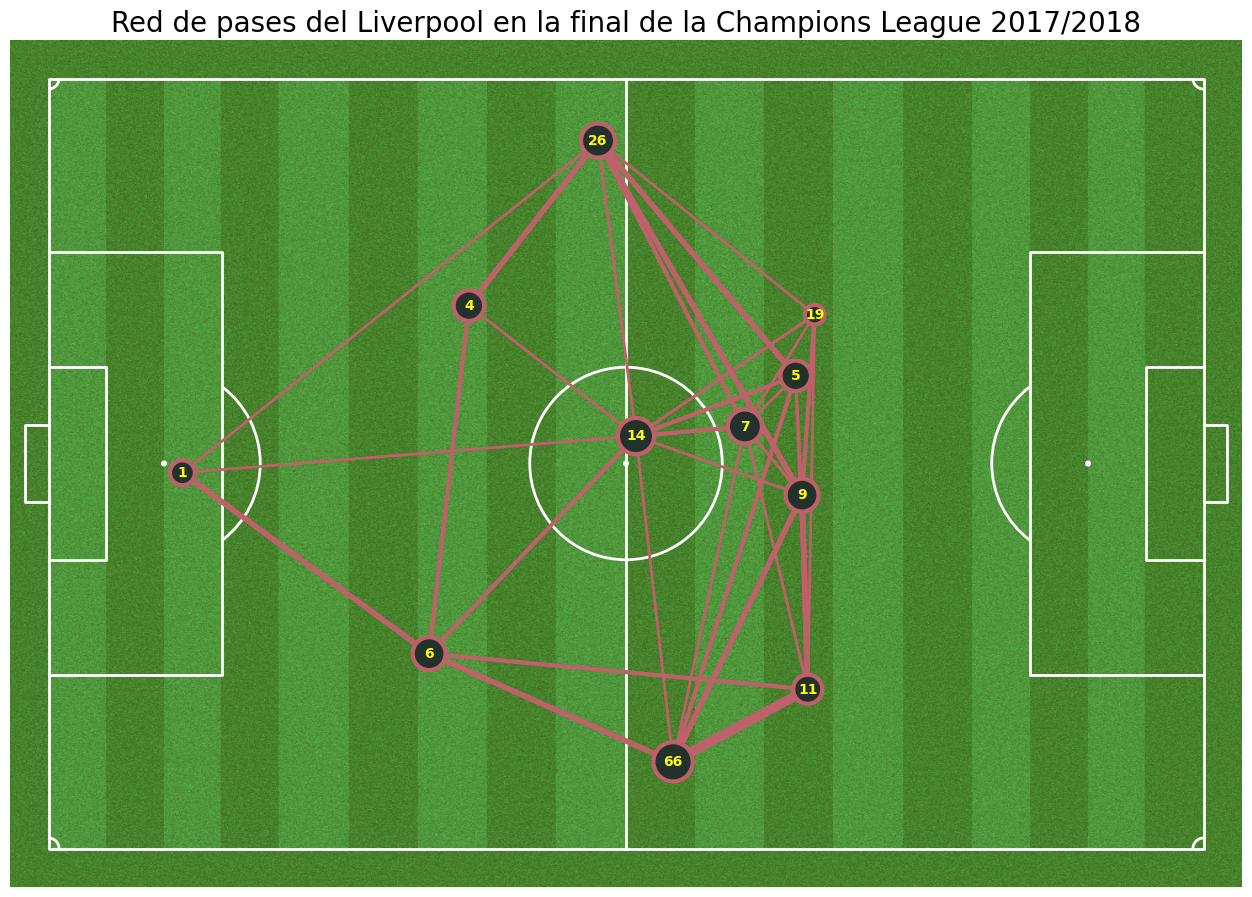

In [ ]:
# Plotear mapa de pases
# Configuración del campo
pitch = Pitch(pitch_type = 'statsbomb', pitch_color = 'grass', line_color='white', stripe=True, goal_type="box", corner_arcs=True)
fig, ax = pitch.draw(figsize=(16, 11), constrained_layout=True, tight_layout=False)

# Líneas de pase
pitch.lines(pass_between.x, pass_between.y, pass_between.x_end, pass_between.y_end, lw=pass_between.pass_count, color='#BF616A', zorder=1, ax=ax)

# Nodos de jugadores
pitch.scatter(average_locations.x, average_locations.y, s=average_locations['count'] * 40, color='#22312b', edgecolors='#BF616A', linewidth=3, alpha=1, ax=ax)

# Anotamos el dorsal en cada nodo
for index, row in average_locations.iterrows():
    pitch.annotate(index, xy=(row.x, row.y), c='yellow', va='center', ha='center', size=10, weight='bold', ax=ax)

ax.set_title('Red de pases del Liverpool - Final Champions League 2017/2018', fontsize=18, color='white')

# Título
ax_title = ax.set_title(f'Red de pases del Liverpool en la final de la Champions League 2017/2018', fontsize=20, color= "Black")

plt.show()